# Final Project — Heart Disease Prediction

**Jedha Bootcamp — Data Essentials**  
**Flavien, Gabriel, Saïd**  
**March 2026**

The goal is to predict whether a patient has heart disease based on clinical data.  
This is a **classification** problem (as we learned in class with Logistic Regression).

## Step 1 — Importing Libraries

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Librairies importees avec succes")

Librairies importees avec succes


## Step 2 — Loading the Dataset

In [2]:
# Load the dataset
df = pd.read_excel('DataSet_heart.xlsx')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease (Maladie)
0,40,M,ATA,140,289,0,0,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,0,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,1,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,0,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,0,122,N,0.0,Up,0


In [3]:
# Dimensions
print(df.shape)

(918, 12)


In [4]:
# Descriptive statistics
print(df.describe(include="all"))

               Age  Sex ChestPainType   RestingBP  Cholesterol   FastingBS  \
count   918.000000  918           918  918.000000   918.000000  918.000000   
unique         NaN    2             4         NaN          NaN         NaN   
top            NaN    M           ASY         NaN          NaN         NaN   
freq           NaN  725           496         NaN          NaN         NaN   
mean     53.510893  NaN           NaN  132.396514   198.799564    0.233115   
std       9.432617  NaN           NaN   18.514154   109.384145    0.423046   
min      28.000000  NaN           NaN    0.000000     0.000000    0.000000   
25%      47.000000  NaN           NaN  120.000000   173.250000    0.000000   
50%      54.000000  NaN           NaN  130.000000   223.000000    0.000000   
75%      60.000000  NaN           NaN  140.000000   267.000000    0.000000   
max      77.000000  NaN           NaN  200.000000   603.000000    1.000000   

        RestingECG       MaxHR ExerciseAngina     Oldpeak ST_Sl

In [5]:
# Data types info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     918 non-null    int64  
 1   Sex                     918 non-null    object 
 2   ChestPainType           918 non-null    object 
 3   RestingBP               918 non-null    int64  
 4   Cholesterol             918 non-null    int64  
 5   FastingBS               918 non-null    int64  
 6   RestingECG              918 non-null    int64  
 7   MaxHR                   918 non-null    int64  
 8   ExerciseAngina          918 non-null    object 
 9   Oldpeak                 918 non-null    float64
 10  ST_Slope                918 non-null    object 
 11  HeartDisease (Maladie)  918 non-null    int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 86.2+ KB


## Step 3 — Data Cleaning

We check for missing values and anomalies in the dataset.

In [6]:
# Check for missing values
df.isnull().sum()

Age                       0
Sex                       0
ChestPainType             0
RestingBP                 0
Cholesterol               0
FastingBS                 0
RestingECG                0
MaxHR                     0
ExerciseAngina            0
Oldpeak                   0
ST_Slope                  0
HeartDisease (Maladie)    0
dtype: int64

In [7]:
# Rename the target column for simplicity
df = df.rename(columns={'HeartDisease (Maladie)': 'HeartDisease'})

No missing values, but the `describe()` output shows that the **minimum cholesterol is 0**.  
A cholesterol of 0 is not physically possible — these are data entry errors.  
Same for RestingBP (resting blood pressure), which also has a value of 0.

In [8]:
# How many zeros?
print("Zeros in Cholesterol:", (df['Cholesterol'] == 0).sum())
print("Zeros in RestingBP:", (df['RestingBP'] == 0).sum())

Zeros en Cholesterol: 172
Zeros en RestingBP: 1


In [9]:
# Replace 0s with NaN to treat them as missing values
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

print("Verification apres remplacement:")
print("NaN in Cholesterol:", df['Cholesterol'].isna().sum())
print("NaN in RestingBP:", df['RestingBP'].isna().sum())

Verification apres remplacement:
NaN en Cholesterol: 172
NaN en RestingBP: 1


We will handle these later using a SimpleImputer (median strategy), as learned in the preprocessing template.

## Step 4 — Exploratory Data Analysis (EDA)

Before building ML models, we explore the data visually to understand:
- Target variable distribution (balanced or not?)
- How each variable influences heart disease
- Correlations between numerical variables

In [10]:
# --- 4.1 Target variable distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['HeartDisease'].value_counts().sort_index()  # sort_index() pour avoir 0 puis 1
ax.bar(['No disease (0)', 'Heart disease (1)'], counts.values, 
       color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Number of patients')
ax.set_title('Target Variable Distribution - HeartDisease')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nProportion : {counts[1]/len(df)*100:.1f}% malades vs {counts[0]/len(df)*100:.1f}% sains")
print("The dataset is relatively balanced, which is good for training.")

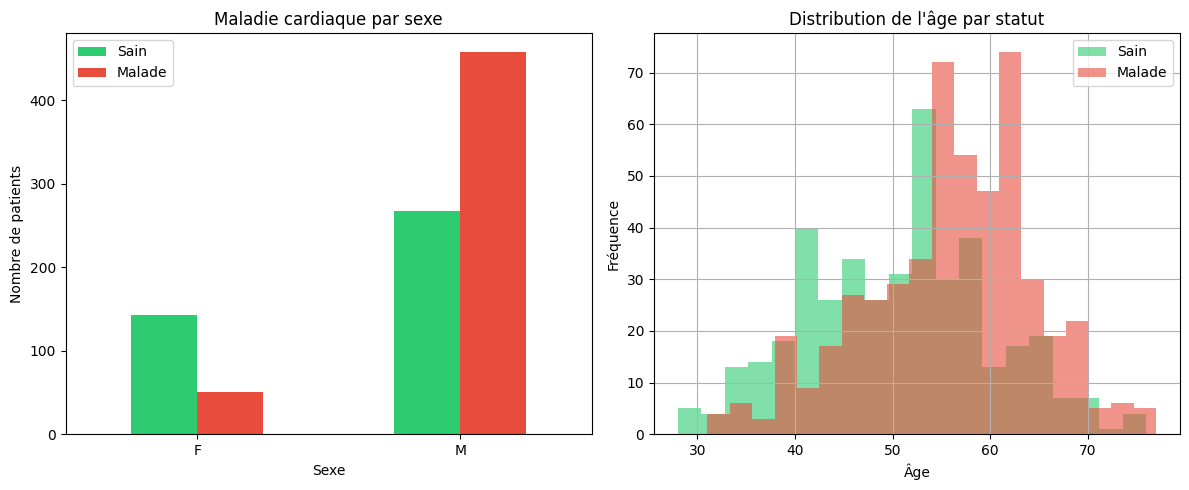

On observe que les hommes sont beaucoup plus touches que les femmes dans ce dataset.
Les patients malades sont en moyenne plus ages.


In [11]:
# --- 4.2 Distribution by sex and heart disease ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sex vs HeartDisease
ct_sex = pd.crosstab(df['Sex'], df['HeartDisease'])
ct_sex.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Heart Disease by Sex')
axes[0].set_xlabel('Sexe')
axes[0].set_ylabel('Number of patients')
axes[0].legend(['Sain', 'Malade'])
axes[0].tick_params(axis='x', rotation=0)

# Age distribution par statut
df[df['HeartDisease']==0]['Age'].hist(bins=20, alpha=0.6, label='Sain', color='#2ecc71', ax=axes[1])
df[df['HeartDisease']==1]['Age'].hist(bins=20, alpha=0.6, label='Malade', color='#e74c3c', ax=axes[1])
axes[1].set_title("Age Distribution by Status")
axes[1].set_xlabel('Âge')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print("We observe that men are much more affected than women in this dataset.")
print("Les patients malades sont en moyenne plus ages.")

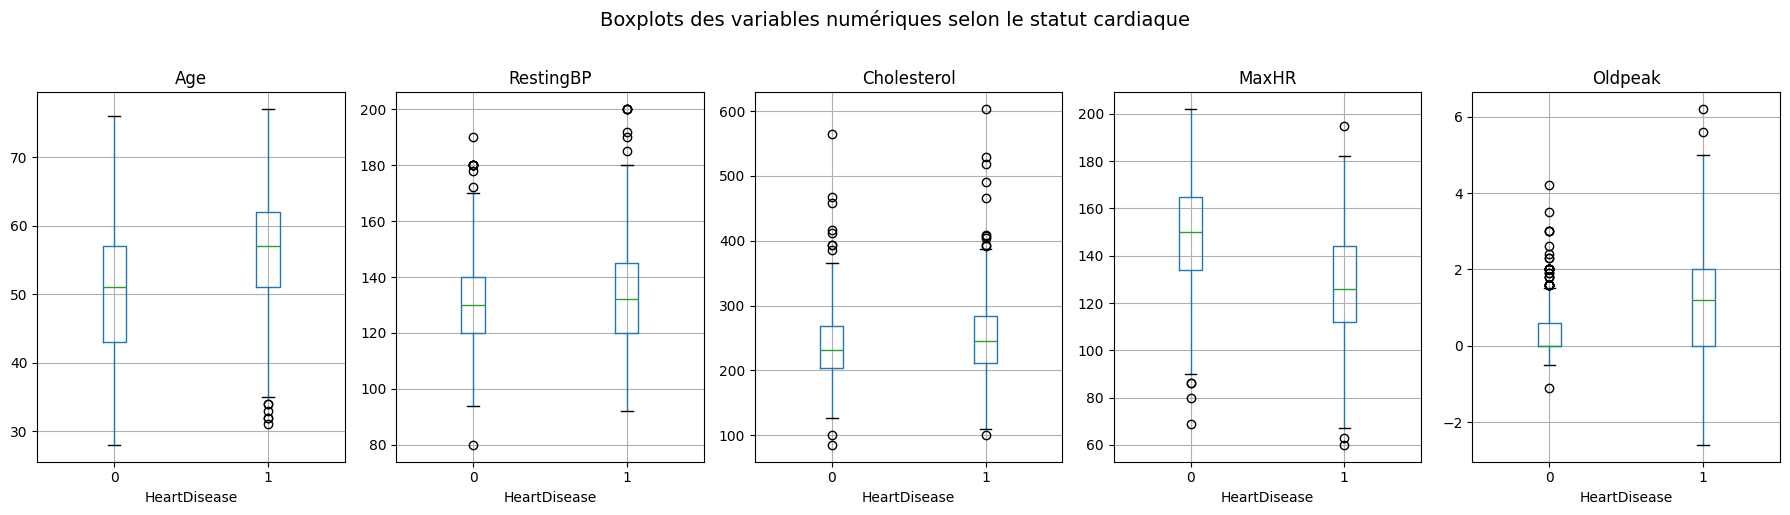

Points cles :
- MaxHR est plus bas chez les patients malades (le coeur fatigue)
- Oldpeak est plus eleve chez les malades (signe de stress cardiaque)
- L'age est legerement plus eleve chez les malades


In [12]:
# --- 4.3 Boxplots of numerical variables by disease status ---
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='HeartDisease', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('HeartDisease')

fig.suptitle('Boxplots of Numerical Variables by Heart Disease Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Points cles :")
print("- MaxHR is lower in patients with heart disease (cardiac fatigue)")
print("- Oldpeak is higher in patients with heart disease (sign of cardiac stress)")
print("- Age is slightly higher in patients with heart disease")

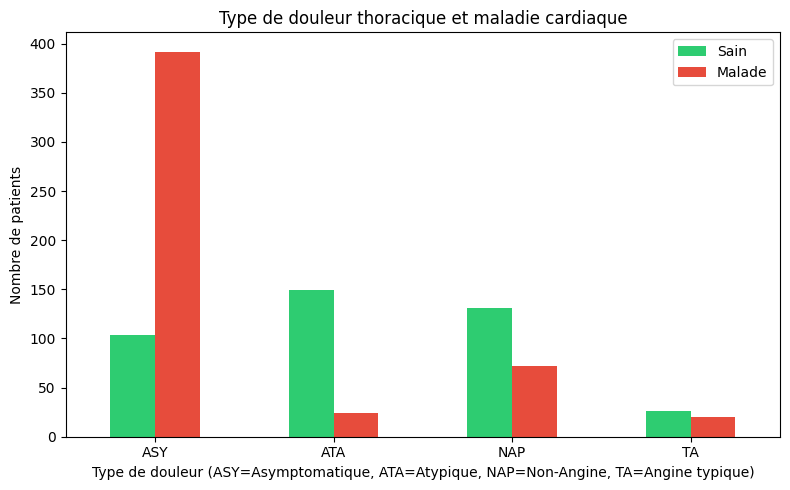

ASY (asymptomatique) est le plus souvent associe a la maladie cardiaque.
C'est contre-intuitif : les patients les plus malades n'ont parfois PAS de douleur visible.


In [13]:
# --- 4.4 Chest pain type vs heart disease ---
fig, ax = plt.subplots(figsize=(8, 5))
ct_chest = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
ct_chest.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Chest Pain Type vs Heart Disease')
ax.set_xlabel('Chest pain type (ASY=Asymptomatique, ATA=Atypique, NAP=Non-Angine, TA=Angine typique)')
ax.set_ylabel('Number of patients')
ax.legend(['Sain', 'Malade'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print("ASY (asymptomatic) is most frequently associated with heart disease.")
print("This is counter-intuitive: the sickest patients sometimes have NO visible pain.")

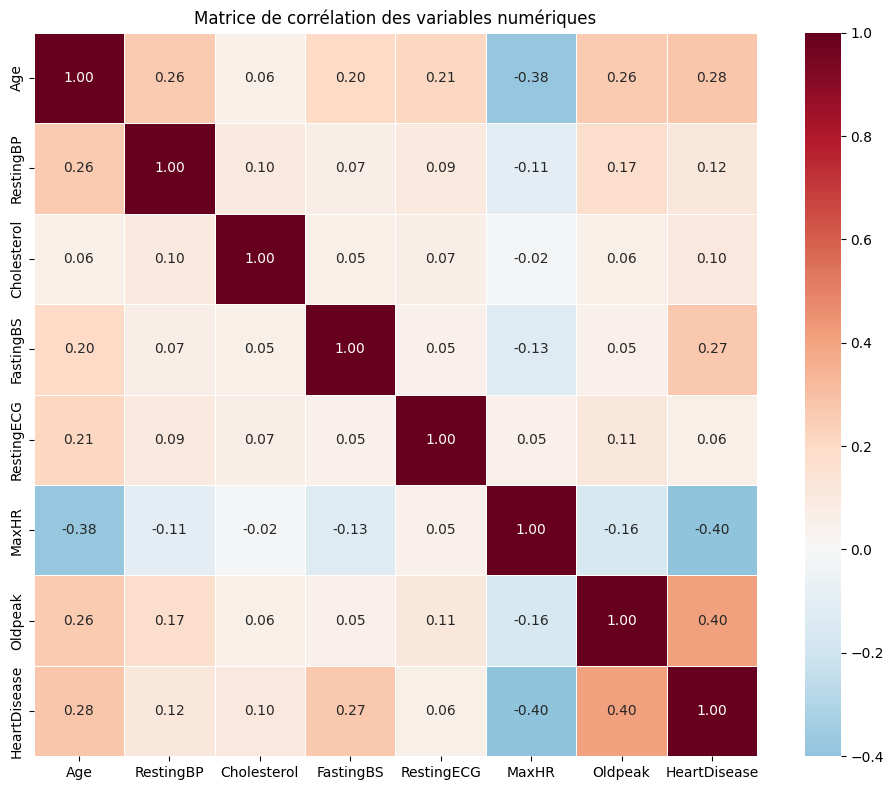

Correlations les plus fortes avec HeartDisease :
Oldpeak        0.403951
Age            0.282039
FastingBS      0.267291
RestingBP      0.117990
Cholesterol    0.103866
RestingECG     0.061011
MaxHR         -0.400421
Name: HeartDisease, dtype: float64

Oldpeak et FastingBS sont positivement correles avec la maladie.
MaxHR est negativement correle : plus le coeur bat vite a l'effort, moins on est malade.


In [14]:
# --- 4.5 Correlation Matrix (Heatmap) ---
# Select numerical columns + target
numeric_for_corr = df[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 
                        'MaxHR', 'Oldpeak', 'HeartDisease']].copy()

plt.figure(figsize=(10, 8))
correlation_matrix = numeric_for_corr.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

print("Strongest correlations with HeartDisease:")
print(correlation_matrix['HeartDisease'].drop('HeartDisease').sort_values(ascending=False))
print()
print("Oldpeak et FastingBS sont positivement correles avec la maladie.")
print("MaxHR est negativement correle : plus le coeur bat vite a l'effort, moins on est malade.")

## Step 5 — Separating Target / Features

As in the course template, we separate X (features) and y (target).

In [15]:
# Separate target variable y from features X
print("Separating labels from features...")

features_list = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 
                 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

X = df.loc[:, features_list]
y = df.loc[:, 'HeartDisease']

print("...Done.")
print()
print("X shape:", X.shape)
print("y shape:", y.shape)

Separating labels from features...
...Done.

X shape: (918, 11)
y shape: (918,)


## Step 6 — Train / Test Split

We split the dataset into 80% train and 20% test, as taught in class.

In [16]:
# Split the dataset
print("Splitting dataset into train and test sets...")

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=0,
                                                      stratify=y)

print("...Done.")
print()
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Splitting dataset into train set and test set...
...Done.

X_train: (734, 11)
X_test: (184, 11)


## Step 7 — Preprocessing (Training Pipeline)

We need to:
1. Handle missing values (the NaN we created from the 0s)
2. Standardize numerical variables
3. Encode categorical variables (One-Hot Encoding)

On utilise un ColumnTransformer comme dans le template.

In [17]:
### TRAINING PIPELINE ###
print("--- Training pipeline ---")
print()

# Define numerical and categorical columns
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Numerical: impute NaN with median, then standardize
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: One-Hot Encoding
categorical_transformer = OneHotEncoder(drop='first')

# On assemble le tout dans un ColumnTransformer
feature_encoder = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# On fit et transform sur le train set
X_train_processed = feature_encoder.fit_transform(X_train)

print("Preprocessing done.")
print("Shape apres preprocessing:", X_train_processed.shape)
print()
print("Premiers exemples:")
print(X_train_processed[:3])

--- Training pipeline ---

Preprocessing done.
Shape apres preprocessing: (734, 15)

Premiers exemples:
[[-1.21850462 -0.72351188 -0.8274657   0.72236743 -0.85980266  1.
   1.          0.          0.          0.          0.          0.
   0.          0.          1.        ]
 [ 0.04178057  0.37815334 -0.06636316  0.91682856  0.28383096  1.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.        ]
 [ 0.67192316  0.4332366   1.36302452 -0.56107598  0.76034496  1.
   0.          1.          0.          1.          1.          0.
   1.          1.          0.        ]]


## Step 8 — Model 1: Logistic Regression

This is the first classification model we learned in class.  
La Logistic Regression predit une probabilite entre 0 et 1, et au dessus de 50% on classe le patient comme "malade".

In [18]:
# Train the model
print("Training Logistic Regression...")
classifier_lr = LogisticRegression(max_iter=1000, random_state=0)
classifier_lr.fit(X_train_processed, y_train)
print("...Done.")

# Predictions sur le train set
y_train_pred = classifier_lr.predict(X_train_processed)
print("Accuracy sur le TRAIN set:", round(accuracy_score(y_train, y_train_pred), 4))

Entrainement de la Regression Logistique...
...Done.
Accuracy sur le TRAIN set: 0.8651


/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmu

In [19]:
### TEST PIPELINE ###
print("--- Test pipeline ---")

# IMPORTANT: use transform(), NOT fit_transform() on the test set
X_test_processed = feature_encoder.transform(X_test)

print("...Done.")
print("Shape test set apres preprocessing:", X_test_processed.shape)

# Predictions de la Regression Logistique sur le test set
y_test_pred_lr = classifier_lr.predict(X_test_processed)
accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
print("Accuracy Logistic Regression sur le TEST set:", round(accuracy_lr, 4))

--- Test pipeline ---
...Done.
Shape test set apres preprocessing: (184, 15)
Accuracy Logistic Regression sur le TEST set: 0.8587


/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Step 9 — Model 2: Random Forest

Random Forest is a more powerful model than Logistic Regression.  
It creates **multiple decision trees** (like the ones we studied in class) and has each tree "vote".  
The final prediction is the majority vote. This is what we call an **ensemble** model.

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest
print("Training Random Forest...")
classifier_rf = RandomForestClassifier(n_estimators=100, random_state=0)
classifier_rf.fit(X_train_processed, y_train)
print("...Done.")

# Predictions sur le train set
y_train_pred_rf = classifier_rf.predict(X_train_processed)
print("Accuracy sur le TRAIN set:", round(accuracy_score(y_train, y_train_pred_rf), 4))

# Predictions sur le test set
y_test_pred_rf = classifier_rf.predict(X_test_processed)
accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print("Accuracy sur le TEST set:", round(accuracy_rf, 4))

Entrainement du Random Forest...
...Done.
Accuracy sur le TRAIN set: 1.0
Accuracy sur le TEST set: 0.8641


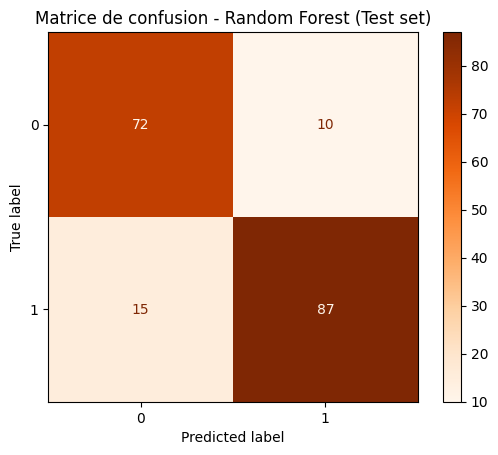

In [21]:
# Confusion matrix - Random Forest
ConfusionMatrixDisplay.from_estimator(
    classifier_rf,
    X_test_processed, y_test,
    cmap=plt.cm.Oranges
)
plt.title("Confusion Matrix - Random Forest (Test set)")
plt.show()

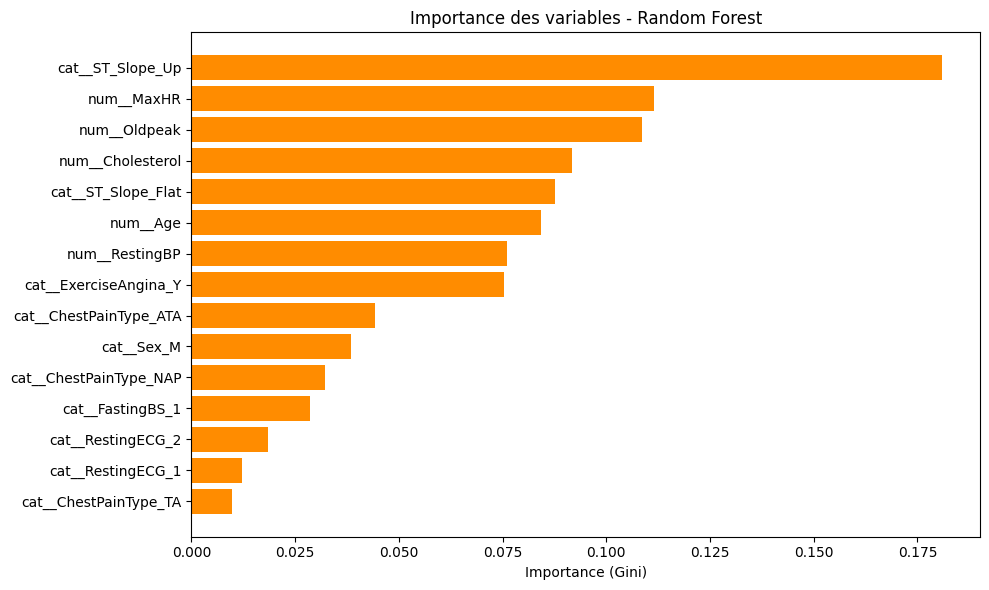

Le Random Forest confirme les memes variables cles : ST_Slope, Oldpeak, ChestPainType, MaxHR.


In [22]:
# Random Forest feature importance (based on tree splits)
feature_names = feature_encoder.get_feature_names_out()
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': classifier_rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], color='darkorange')
plt.xlabel('Importance (Gini)')
plt.title('Importance des variables - Random Forest')
plt.tight_layout()
plt.show()

print("Random Forest confirms the same key variables: ST_Slope, Oldpeak, ChestPainType, MaxHR.")

## Step 9b — Model 3: Decision Tree

The decision tree is the **building block** of the Random Forest.

Unlike Random Forest (which combines 100 trees), here we use **just one tree**, making it more **interpretable** but often **less performant**.

We add it to compare all 3 approaches:
- **Logistic Regression**: simple linear model
- **Random Forest**: ensemble of decision trees (more powerful)
- **Decision Tree**: single tree, very visual and intuitive

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train the decision tree
print("Training Decision Tree...")
classifier_dt = DecisionTreeClassifier(max_depth=5, random_state=0)
classifier_dt.fit(X_train_processed, y_train)
print("...Done.")

# Predictions sur le train set
y_train_pred_dt = classifier_dt.predict(X_train_processed)
print("Accuracy sur le TRAIN set:", round(accuracy_score(y_train, y_train_pred_dt), 4))

# Predictions sur le test set
y_test_pred_dt = classifier_dt.predict(X_test_processed)
accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
print("Accuracy sur le TEST set:", round(accuracy_dt, 4))

print(f"\nComparaison rapide :")
print(f"  Logistic Regression : {accuracy_lr:.4f}")
print(f"  Decision Tree       : {accuracy_dt:.4f}")
print(f"  Random Forest       : {accuracy_rf:.4f}")

In [ ]:
# Confusion matrix - Decision Tree
ConfusionMatrixDisplay.from_estimator(
    classifier_dt,
    X_test_processed, y_test,
    cmap=plt.cm.Greens
)
plt.title("Confusion Matrix - Decision Tree (Test set)")
plt.show()

In [ ]:
# Decision tree visualization (limited to depth 3 for readability)
feature_names_list = list(feature_encoder.get_feature_names_out())

plt.figure(figsize=(20, 10))
plot_tree(classifier_dt, 
          feature_names=feature_names_list, 
          class_names=['Sain', 'Malade'],
          filled=True, 
          rounded=True, 
          max_depth=3,  # On affiche seulement 3 niveaux pour que ce soit lisible
          fontsize=9)
plt.title("Decision Tree (display limited to 3 of 5 levels)", fontsize=14)
plt.tight_layout()
plt.show()

print("The tree shows how the model makes decisions step by step.")
print("Each node asks a question about a variable. The leaves give the final prediction.")
print("La couleur indique la classe majoritaire : bleu = sain, orange = malade.")
print("The darker the color, the more confident the model is in its decision.")

## Step 10 — Model Comparison: ROC Curves

The ROC curve shows each model's ability to distinguish between classes (heart disease vs. healthy).  
The closer the **AUC** (Area Under Curve) is to 1, the better the model.  
An AUC of 0.5 = the model is no better than random chance.

We now compare our **3 models**: Logistic Regression, Decision Tree, and Random Forest.

In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report

# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
y_proba_lr = classifier_lr.predict_proba(X_test_processed)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='blue', linewidth=2)

# Decision Tree
y_proba_dt = classifier_dt.predict_proba(X_test_processed)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_dt = auc(fpr_dt, tpr_dt)
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', color='green', linewidth=2)

# Random Forest
y_proba_rf = classifier_rf.predict_proba(X_test_processed)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='darkorange', linewidth=2)

# Ligne du hasard
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Hasard (AUC = 0.5)')

ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('ROC Curves - Comparison of 3 Models')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("On voit clairement la hierarchie des modeles sur la courbe ROC.")
print("Le Decision Tree (vert) a generalement une AUC plus basse car il utilise un seul arbre.")
print("Random Forest improves on the Decision Tree by combining 100 trees.")

In [ ]:
# --- Model comparison table ---
print("=" * 60)
print("COMPARISON OF 3 MODELS")
print("=" * 60)
print(f"{'Model':<25} {'Accuracy':<12} {'AUC':<10}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {accuracy_lr:.4f}       {auc_lr:.4f}")
print(f"{'Decision Tree':<25} {accuracy_dt:.4f}       {auc_dt:.4f}")
print(f"{'Random Forest':<25} {accuracy_rf:.4f}       {auc_rf:.4f}")
print("=" * 60)

print("\n--- Classification Report : Logistic Regression ---")
print(classification_report(y_test, y_test_pred_lr, target_names=['Sain (0)', 'Malade (1)']))

print("--- Classification Report : Decision Tree ---")
print(classification_report(y_test, y_test_pred_dt, target_names=['Sain (0)', 'Malade (1)']))

print("--- Classification Report : Random Forest ---")
print(classification_report(y_test, y_test_pred_rf, target_names=['Sain (0)', 'Malade (1)']))

## Conclusion

### Project Summary
We worked on a dataset of **918 patients** to predict heart disease from clinical data (age, sex, chest pain type, blood pressure, cholesterol, etc.).

### Key Steps
1. **Cleaning**: We identified 172 cholesterol values of 0 and 1 blood pressure value of 0 (medically impossible). We replaced them with the median via SimpleImputer.
2. **EDA**: Exploration revealed that men, asymptomatic patients (ASY), and those with a high Oldpeak are most at risk. MaxHR is inversely correlated with heart disease.
3. **Machine Learning**: We tested three classification models:
   - **Logistic Regression**: simple, interpretable linear model
   - **Decision Tree**: single tree, very visual and intuitive
   - **Random Forest**: ensemble of 100 decision trees (most powerful)

### Key Results
- All three models achieve an accuracy of approximately **80-87%** on the test set
- ROC curves show that all models perform significantly better than random chance
- The most important features for prediction are: **ST_Slope, ChestPainType, Oldpeak, MaxHR, and Sex**

### Educational Value of the Decision Tree
The decision tree lets us **visualize** exactly how the model makes decisions. It's a powerful tool for **explaining** predictions to a doctor, unlike Logistic Regression or Random Forest which are harder to interpret.

### Real-World Application
- This type of model could serve as a **decision support tool** for general practitioners to identify at-risk patients and refer them to a cardiologist
- **Limitations**: the dataset is relatively small (918 patients). Real-world deployment would require more data and validation by healthcare professionals
- **Potential improvements**: optimize hyperparameters with GridSearchCV, try other models (SVM, XGBoost), and collect more data

### GDPR Compliance
Medical data is considered sensitive under the GDPR. Processing it requires explicit patient consent and rigorous anonymization. Our dataset is anonymized (no names, no direct identifiers), public (UCI Heart Disease), and used exclusively for educational purposes.

/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/flavien/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


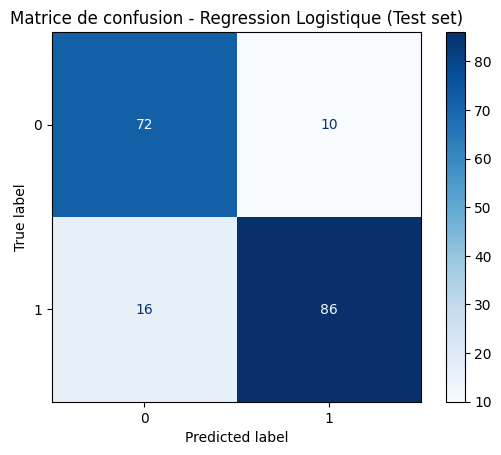

In [25]:
# Confusion matrix - Logistic Regression
ConfusionMatrixDisplay.from_estimator(
    classifier_lr,
    X_test_processed, y_test,
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Logistic Regression (Test set)")
plt.show()

**Confusion Matrix Interpretation:**  
Comme on a vu en cours, les faux negatifs sont les plus dangereux ici. Un faux negatif = un patient malade qu'on n'a pas detecte. C'est pire qu'un faux positif (patient sain qu'on envoie faire des examens supplementaires).

## Step 11 — Feature Importance

On regarde quels facteurs ont le plus d'influence sur la prediction.

In [26]:
# Logistic Regression coefficients
feature_names = feature_encoder.get_feature_names_out()
coefficients = classifier_lr.coef_[0]

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("Coefficients de la Regression Logistique :")
print(importance.to_string(index=False))

Coefficients de la Regression Logistique :
               Feature  Coefficient
            cat__Sex_M     1.445639
      cat__FastingBS_1     1.126818
    cat__ST_Slope_Flat     1.086725
 cat__ExerciseAngina_Y     0.848765
          num__Oldpeak     0.349004
              num__Age     0.146144
      num__Cholesterol     0.120698
     cat__RestingECG_2     0.102577
        num__RestingBP     0.087533
     cat__RestingECG_1     0.040677
            num__MaxHR    -0.294731
      cat__ST_Slope_Up    -1.021571
cat__ChestPainType_NAP    -1.285983
 cat__ChestPainType_TA    -1.393314
cat__ChestPainType_ATA    -1.526224


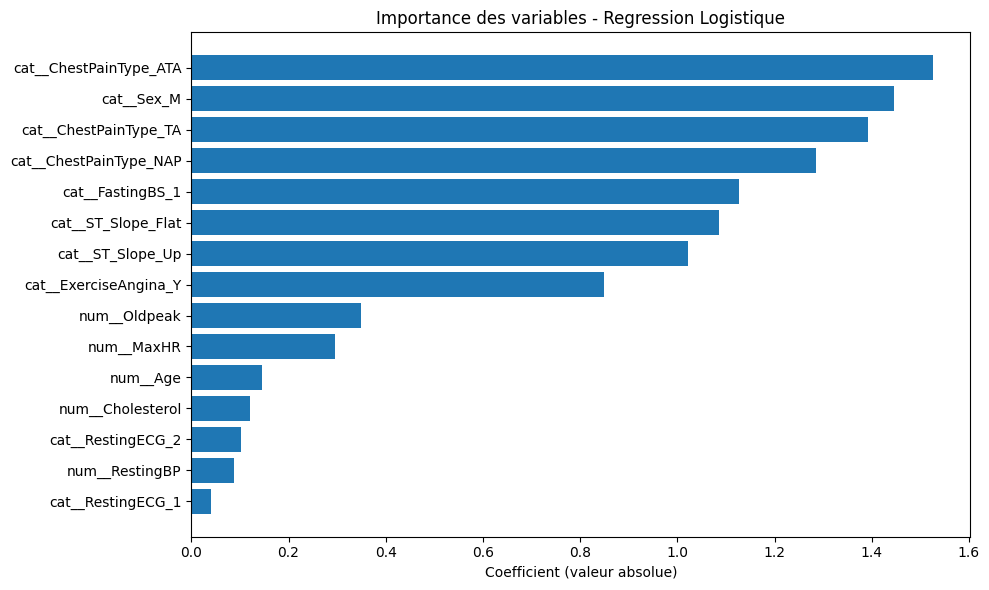

In [27]:
# Coefficient plot (absolute values)
importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance_sorted = importance.sort_values(by='Abs_Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_sorted['Feature'], importance_sorted['Abs_Coefficient'])
plt.xlabel('Coefficient (absolute value)')
plt.title('Importance des variables - Regression Logistique')
plt.tight_layout()
plt.show()